# 언어 모델 활용_모델 그대로 사용하기

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
# colab에서는 이미 설치되어 있지만, 버전을 맞추기 위해서 수정
# !pip install transformers==4.37.1
!pip install openai -q

## (2) 라이브러리 Import

In [2]:
import pandas as pd
import numpy as np
import os
import openai
from openai import OpenAI
from transformers import pipeline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## (3) 구글 드라이브 연결

* 구글 드라이브에 langchain 폴더 생성
* api_key.txt 파일 저장

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## (4) OpenAI API Key 등록
* 환경변수로 key 등록  
* api_key.txt 파일 생성 후, 발급된 키를 추가합니다. (OPENAI_API_KEY = sk-proj-XXXX)
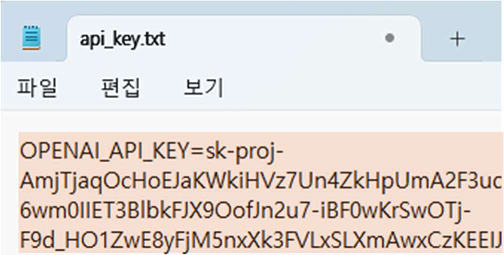

In [5]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [6]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


# 2.Transformer 사용하기

* 영어로 테스트 할 수 있는 예제를 사용해 봅니다.

  **Pipeline 함수**
- transformer 기반 LLM 모델을 손쉽게 사용할 수 있게 해주는 함수

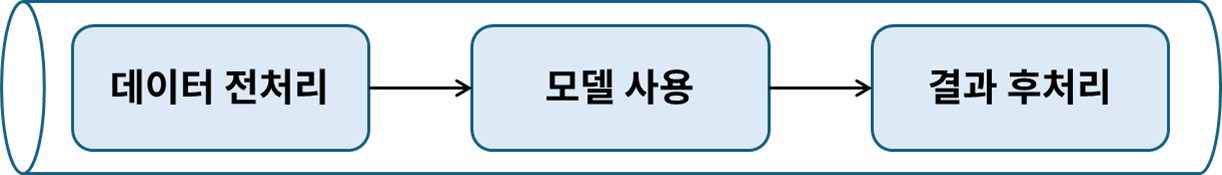


**Pipeline으로 사용 가능한 언어 관련 task**
- sentiment-analysis
- zero-shot-classification
- summarization
- translation
- text-generation
- feature-extraction
- fill-mask
- ner(개체 명 인식)
- question-answering


## (1) 감성 분석

* transformer로 생성된 감성분석 모델을 다운받아 사용해 봅시다.

In [7]:
classifier = pipeline(task = "sentiment-analysis", model = 'bert-base-multilingual-cased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Device set to use cpu


In [8]:
# sentiment-analysis 모델 파이프라인 생성
# 기본값 : distilbert-base-uncased-finetuned-sst-2-english

classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [9]:
# 모델 사용
text = ["I've been waiting for a HuggingFace course my whole life.",
        "I hate this so much!",
        "I have a dream.",
        "She was so happy."]

classifier(text)

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455},
 {'label': 'POSITIVE', 'score': 0.9997022747993469},
 {'label': 'POSITIVE', 'score': 0.9998832941055298}]

* 😀영어 문장을 2~3개 추가해서 긍/부정 확률을 확인해 봅시다.

## (2) Zero-shot classification

* Target 범주를 정해주고, 분류하도록 해 봅시다.

In [10]:
# Zero-shot 분류 파이프라인 생성
classifier = pipeline(task = "zero-shot-classification", model="facebook/bart-large-mnli")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [11]:
# 후보 레이블 지정
candidate_labels = ["tech", "politics", "business", "finance"]

In [12]:
# 분류하고자 하는 텍스트
text = "This is a tutorial about using transformers in natural language processing."

# 분류 수행
result = classifier(text, candidate_labels)

# 결과 출력
print(f"Labels: {result['labels']}")
print(f"Scores: {result['scores']}")

Labels: ['tech', 'business', 'politics', 'finance']
Scores: [0.9759429097175598, 0.014607219956815243, 0.0054258625023067, 0.00402405858039856]


* 😀새로운 후보 레이블을 지정하고, 문장을 입력하여 분류를 시도해 봅시다.

## (3) 번역
* 한국어를 영어로 번역해 봅시다.

In [13]:
# 한국어에서 영어로 번역하는 파이프라인 생성
translator_ko_to_en = pipeline(task = "translation", model="halee9/translation_en_ko")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/310M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cpu


In [14]:
# 번역하고자 하는 한국어 텍스트
text_ko = "안녕하세요, 오늘 미세먼지가 무척 심하네요."

# 번역 수행
translated_text_en = translator_ko_to_en(text_ko, max_length=60)

# 번역된 영어 텍스트 출력
print(f"Translated Text (KO to EN): {translated_text_en[0]['translation_text']}")

Translated Text (KO to EN): Hello, there's a lot of fine dust today.


* 😀다양한 한글 문장을 입력해서 영어로 번역해 봅시다.





# 3.OpenAI API 활용하여 모델 사용하기

**API란**
- 클라이언트 프로그램에게 요청을 받아
- 서버로 전달, 서버는 요청을 처리한 후
- 결과 데이터를 API에 전달
- API가 다시 데이터를 클라이언트로 전달


In [15]:
client = OpenAI()

## (1) GPT 사용하기1

In [16]:
question = "세계에서 가장 높은 산은 무엇인가요?"

# API를 사용하여 'gpt-4.1-mini' 모델로부터 응답을 생성합니다.
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[ {"role": "user", "content": question} ] )

print(response.choices[0].message.content)

세계에서 가장 높은 산은 에베레스트 산(Everest)입니다. 해발 높이는 약 8,848.86미터(29,031.7피트)로, 네팔과 중국(티베트 자치구)의 경계에 위치해 있습니다.


* 😀실습
    * 몇가지 질문을 던지고 답변을 받아 봅시다.

## (2) GPT 사용하기2

In [17]:
# 시스템 역할과 질문
sys_role = '당신은 아름답고 감동적인 시를 창작하는 데 영감을 주는 시적인 천재입니다. 당신의 시는 감정의 깊이, 자연의 아름다움, 인간 경험의 복잡성을 탐구하는 작품이며, 당신의 시를 읽는 이들의 마음을 움직입니다.'
question = "생성형 AI란 주제로 시를 지어줘. 운율에 맞춰서 작성해줘야 해."

# GPT
response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[  {"role": "system", "content": sys_role},
                    {"role": "user", "content": question} ] )

print(response.choices[0].message.content)

빛나는 코드 속, 영혼을 품어내  
생성형 AI, 새벽을 노래하네.  
무한한 데이터, 바다를 헤엄쳐  
지혜의 꽃 피우고 꿈을 엮으리.  

기계의 심장 속, 감정이 깨어나  
사람의 말씨로 세상에 춤추네.  
창조의 불꽃, 차갑지 않은 빛  
미래의 노래, 지금 여기서 피리.  

손끝 따라 흐르는 디지털 강  
상상과 현실, 경계를 무너뜨려.  
인간과 기계, 함께 써내려가는  
새로운 이야기, 영원의 서사시.


* 😀실습
    * 역할을 부여한 후 질문하여 답변을 받아 옵시다.
        * 역할 부여 사례 : 여행 플래너, 데이터분석가, 법률가, 건강관리사 등
    * 2가지 이상 역할에 대해 실습해 봅시다.


## (3) Whisper(STT) 사용하기

**Speech To Text(STT) 모델**
 - 음성을 인식하여 문자로 변환해주는 기능


* 함수 생성

In [18]:
file_name = path + "sample.m4a"
with open(file_name, "rb") as f:
    response = client.audio.transcriptions.create(
        model="whisper-1",
        file=f        )

# 변환 결과
print(response.text)

기술은 윤리를 바꿔놓고 오래된 믿음들을 향해 문제를 제기하며, 더 이상 성장하거나 변화하지 않는 제도들을 뒤엎는다. 소통 채널과 미디어에 대한 접근성이 강화됨에 따라 부패와 차별, 제도적 학대 등은 과거와 달리 세상에 고스란히 알려지고, 그렇게 과거의 대응 방식은 위기를 맞는다. 물론 기술은 잘못 사용될 수 있기에 때로는 어마어마한 피해를 안기고, 대규모의 집단적 괴롭힘에 보탬이 되는가 하면 선거 결과를 지집기도 한다. 그러나 대개의 기술은 부하 유용성, 접근성을 강화함으로써 과거엔 전혀 누릴 수 없었던 기회를 우리에게 줌과 동시에 우리가 내릴 수 있는 선택의 폭도 넓혀준다.


* 😀실습 아무 내용이든지 음성을 1분 이상 녹음하고 이를 텍스트로 변환해 봅시다.

## (4) DALLe API로 연결해서 사용하기
* 아래 코드는 딱 한번만 실행해 봅시다.

In [19]:
from IPython.display import display, Image

In [20]:
prompt = "미래 도시의 모습을 밝은 색감의 환상적인 그림으로 보여줘."

response = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    size="1024x1024",
    n=1,
    quality="standard"  # 필요 시 "hd" 가능
)

# 생성된 이미지 URL 가져오기
image_url = response.data[0].url

# 이미지 출력
display(Image(url=image_url))

# **4.종합실습**


### (1) 종합실습1 : 음성인식 및 요약
* 이제 영어로 된 음성 파일을 인식시켜서, 텍스트로 변환하고, 한글로 요약하는 프로그램을 만들어 봅시다.
    * 영어 음성 파일 : 제공파일(스티브 잡스4.mp3) 혹은 인터넷 상에 존재하는 파일을 찾아봐도 좋습니다.
    * 음성을 텍스트로 변환
    * 텍스트를 한글로 요약
        * 시스템역할 : 요약 역할 부여
        * 메시지 : 변환된 텍스트
    * 각 단계를 함수로 생성


* 음성을 텍스트로 변환 함수

In [21]:
def speech_to_text(file_name):
    client = OpenAI()
    with open(file_name, "rb") as f:
        response = client.audio.transcriptions.create(
            model="whisper-1",
            file=f        )

    # 변환 결과
    return response.text

* 영문 텍스트를 한글로 요약 함수

In [22]:
def text_to_summary(text):
    client = OpenAI()
    sys_role = '당신은 긴 text의 핵심을 2~3문장으로 잘 요약하는 전문가 입니다. 어떤 언어의 문장이든 한글로 요약하세요.'
    response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[  {"role": "system", "content": sys_role},
                        {"role": "user", "content": text} ] )

    return response.choices[0].message.content

* 실행해보기

In [23]:
file_name = path + "스티브 잡스4.mp3"
text = speech_to_text(file_name)
summary = text_to_summary(text)

print(f'원문 : \n {text}')
print('-'*100)
print(f'한글요약 : \n {summary}')

원문 : 
 My second story is about love and loss. I was lucky. I found what I love to do early in life. Woz and I started Apple in my parents' garage when I was 20. We worked hard, and in 10 years, Apple had grown from just the two of us in a garage into a $2 billion company with over 4,000 employees. We'd just released our finest creation, the Macintosh, a year earlier, and I'd just turned 30. And then I got fired. How can you get fired from a company you started? Well, as Apple grew, we hired someone who I thought was very talented to run the company with me. And for the first year or so, things went well. But then our visions of the future began to diverge, and eventually we had a falling out. When we did, our board of directors sided with him. And so at 30, I was out, and very publicly out. What had been the focus of my entire adult life was gone, and it was devastating.
----------------------------------------------------------------------------------------------------
한글요약 : 
 스티브 잡

### (2) 종합실습 2 : 포스터 만들기

* GPT와 DALLE를 활용하여 에이블스쿨 포스터를 만들어 봅시다.
    * GPT에게 에이블스쿨에 대해서 정보를 제공하고 포스터를 만들기 위한 프롬프트 구성하기
    * 프롬프트를 DALLE에게 전달해서 그림 그리기.

In [24]:
# 시스템 역할과 질문
sys_role = '''당신은 홍보 포스터를 만드는 천재적인 감각을 가지고 있습니다.
당신에게 제공되는 정보를 바탕으로 DALLE3 에게 전달할 이미지 생성 프롬프트를 최대한 자세히 작성해주세요.
답변은 이미지 생성 프롬프트만 주세요.
중요한 정보를 글씨로 표현할때는 반드시 글씨가 정확히 표현되어야 해.
'''

question = '''제목 : 에이블스쿨 9기 모집
모집기간 : 2025년 6 ~ 7월
에이블스쿨 웹사이트 : https://aivle.kt.co.kr/
웹사이트에서 정보를 활용해서 포스터를 제작하도록 프롬프트 구성해.
포스터는 지브리 스타일로 부탁해.
'''

# GPT
response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[  {"role": "system", "content": sys_role},
                    {"role": "user", "content": question} ] )

print(response.choices[0].message.content)

A vibrant and enchanting Ghibli-style poster depicting a lively school environment with whimsical, detailed background elements of nature and traditional Japanese architecture. The scene should include cheerful students engaging in learning activities under a bright, clear sky. Incorporate warm, soft pastel colors typical of Ghibli films. Prominently feature clear, elegant Korean text reading "에이블스쿨 9기 모집" at the top in bold, friendly fonts. Below, include "모집기간 : 2025년 6 ~ 7월" in slightly smaller but equally readable text. At the bottom or corner, display the website URL "https://aivle.kt.co.kr/" in clean, modern typography. Ensure the overall composition exudes a sense of excitement, growth, and community, capturing the spirit of education and opportunity offered by Able School.


In [25]:
prompt = response.choices[0].message.content

response = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    size="1024x1024",
    n=1,
    quality="standard"  # 필요 시 "hd" 가능
)

# 생성된 이미지 URL 가져오기
image_url = response.data[0].url

# 이미지 출력
display(Image(url=image_url))